In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np



/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

def entropy(array):
    _, counts = np.unique(array, return_counts=True)
    probabilities = counts / len(array)
    shannon_entropy = -np.sum(probabilities * np.log2(probabilities))
    
    return shannon_entropy

In [3]:
pre_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PSI/ROTAMERS/preLC3B_OPLS_psi_rotamers_all.csv", index_col=0)
pre_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PHI/ROTAMERS/preLC3B_OPLS_phi_rotamers_all.csv", index_col=0)


pre_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/SC/CHI1/ROTAMERS/preLC3B_OPLS_chi1_rotamers.csv", index_col=0)


In [4]:
unb_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_II_ER_protein/BB/PSI/ROTAMERS/LC3B_II_ER_protein_psi_rotamers_all.csv", index_col=0)
unb_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_II_ER_protein/BB/PHI/ROTAMERS/LC3B_II_ER_protein_phi_rotamers_all.csv", index_col=0)


unb_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_II_ER_protein/SC/CHI1/ROTAMERS/LC3B_II_ER_protein_chi1_rotamers.csv", index_col=0)


In [5]:
def num_ext(DF, angle):
    FORM_dih_sel_col=[]
    for i in DF.columns:
        j=i.split('.')[0].replace(angle,'')
        t_ls=re.findall(r'\d+', j)
        t=int(''.join(t_ls))
        FORM_dih_sel_col.append(t)
    return(FORM_dih_sel_col)

def entropy_ret(rot_dat,angle_):
    rot_dat_ent_df=pd.DataFrame()
    rot_dat_ent=[]
    for i in rot_dat.columns:

        ls=rot_dat[i].to_numpy()
        rot_dat_ent.append(entropy(ls))
    
    rot_dat_ent_df['Residues']=num_ext(rot_dat, angle_)
    rot_dat_ent_df[angle_]= rot_dat_ent   
    return rot_dat_ent_df

In [6]:
pre_psi_entropy=entropy_ret(pre_psi_rotamers_df, 'psi')
pre_phi_entropy=entropy_ret(pre_phi_rotamers_df, 'phi')


pre_chi1_entropy=entropy_ret(pre_chi1_rotamers_df, 'chi1')
# pre_chi2_entropy=entropy_ret(pre_chi2_rotamers_df, 'chi2')
# pre_chi3_entropy=entropy_ret(pre_chi3_rotamers_df, 'chi3')
# pre_chi4_entropy=entropy_ret(pre_chi4_rotamers_df, 'chi4')


pre_entropy_merger1=pd.merge(pre_psi_entropy, pre_phi_entropy, on='Residues', how='outer')
pre_entropy_merger2=pd.merge(pre_entropy_merger1, pre_chi1_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi2_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi3_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi4_entropy, on='Residues', how='outer')

pre_entropy_merger2=pre_entropy_merger2.fillna(0)
pre_entropy_merger2

,Residues,psi,phi,chi1
0,1,0.242109,0.994710,1.062783
1,2,0.964763,-0.000000,0.215513
2,3,0.904758,0.386450,1.463197
3,4,0.797402,0.014644,0.677710
4,5,0.621834,0.097914,1.457166
...,...,...,...,...
120,121,0.631530,0.531883,1.151683
121,122,0.981568,0.004327,1.551311
122,123,0.576848,0.004327,1.168260
123,124,0.993309,0.243634,1.193351


In [7]:
unb_psi_entropy=entropy_ret(unb_psi_rotamers_df, 'psi')
unb_phi_entropy=entropy_ret(unb_phi_rotamers_df, 'phi')


unb_chi1_entropy=entropy_ret(unb_chi1_rotamers_df, 'chi1')
# unb_chi2_entropy=entropy_ret(unb_chi2_rotamers_df, 'chi2')
# unb_chi3_entropy=entropy_ret(unb_chi3_rotamers_df, 'chi3')
# unb_chi4_entropy=entropy_ret(unb_chi4_rotamers_df, 'chi4')


unb_entropy_merger1=pd.merge(unb_psi_entropy, unb_phi_entropy, on='Residues', how='outer')
unb_entropy_merger2=pd.merge(unb_entropy_merger1, unb_chi1_entropy, on='Residues', how='outer')
# unb_entropy_merger2=pd.merge(unb_entropy_merger2, unb_chi2_entropy, on='Residues', how='outer')
# unb_entropy_merger2=pd.merge(unb_entropy_merger2, unb_chi3_entropy, on='Residues', how='outer')
# unb_entropy_merger2=pd.merge(unb_entropy_merger2, unb_chi4_entropy, on='Residues', how='outer')

unb_entropy_merger2=unb_entropy_merger2.fillna(0)
unb_entropy_merger2

,Residues,psi,phi,chi1
0,1,0.921915,0.993493,1.061021
1,2,0.348012,-0.000000,0.688355
2,3,0.757324,0.746777,1.443741
3,4,0.819228,0.074027,1.003669
4,5,0.652722,0.004327,1.015994
...,...,...,...,...
114,115,0.999999,0.017768,1.182967
115,116,0.739805,0.011398,1.376602
116,117,0.941270,0.329846,0.980124
117,118,0.555251,0.315189,1.565442


In [8]:
def net_ent_calc(state_df):
    net_entropy_norm_state=[]
    for a,i,j,k in zip(state_df['Residues'],
                    state_df['psi'],
                    state_df['phi'],
                    state_df['chi1']):

        ent_ls=[i,j,k]
    
        val=sum(ent_ls)
        if val ==0:
            net_entropy_norm_state.append(0)
        else:
            net_entropy_norm_state.append(val/max(ent_ls))

    return net_entropy_norm_state

In [9]:
pre_entropy_merger2['NET_ENTROPY']=net_ent_calc(pre_entropy_merger2)
unb_entropy_merger2['NET_ENTROPY']=net_ent_calc(unb_entropy_merger2)

In [10]:
pre_entropy_merger2

,Residues,psi,phi,chi1,NET_ENTROPY
0,1,0.242109,0.994710,1.062783,2.163755
1,2,0.964763,-0.000000,0.215513,1.223384
2,3,0.904758,0.386450,1.463197,1.882457
3,4,0.797402,0.014644,0.677710,1.868262
4,5,0.621834,0.097914,1.457166,1.493937
...,...,...,...,...,...
120,121,0.631530,0.531883,1.151683,2.010184
121,122,0.981568,0.004327,1.551311,1.635524
122,123,0.576848,0.004327,1.168260,1.497471
123,124,0.993309,0.243634,1.193351,2.036529


In [11]:
#d entropy = UNB ENTROPY - PRE ENTROPY
d_ent_pre_unb=[]
for pre_res, pre_ent,\
unb_res, unb_ent in zip(pre_entropy_merger2.iloc[:119]['Residues'],
                        pre_entropy_merger2.iloc[:119]['NET_ENTROPY'],
                       unb_entropy_merger2.iloc[:119]['Residues'],
                       unb_entropy_merger2.iloc[:119]['NET_ENTROPY']):
    if pre_res!=unb_res:
        print('WARNING!')
        break
    else:
        d_ent_pre_unb.append(unb_ent-pre_ent)

In [12]:
min(d_ent_pre_unb), max(d_ent_pre_unb)

(-1.578523162937704, 1.0)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_94273/1286897331.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


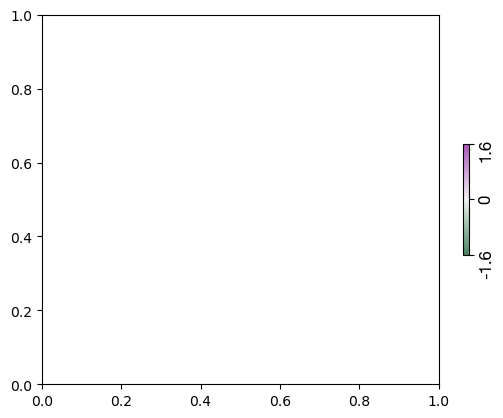

In [14]:

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }
import matplotlib.cm as cm
import matplotlib.colors as colors
from pypalettes import load_cmap


mini=-1.6
maxi=1.6


cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True)
cmp=cmap
norm = colors.Normalize(vmin=mini, vmax=maxi)



f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticks([-1.6, 0, 1.6],[-1.6, 0, 1.6],
                  rotation=90,fontdict=font)

# plt.savefig('shannon_entropy/d_SE_cbar.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

In [20]:
col_ls_all=[]

for i,j in zip([i for i in range(1,120)],d_ent_pre_unb):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_all.append(col)
    


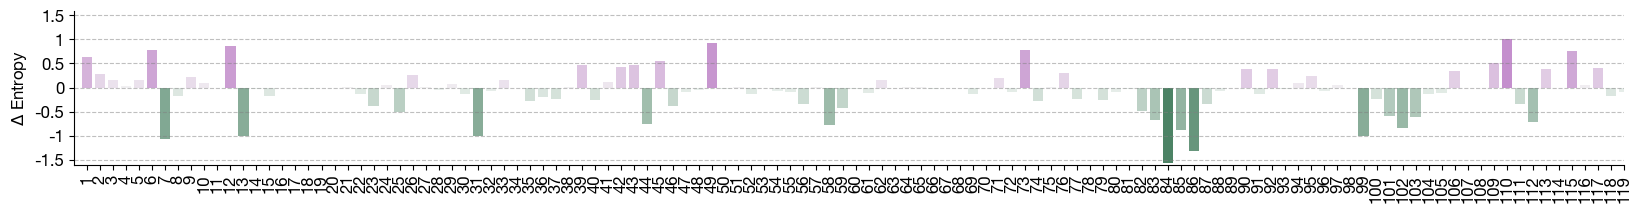

In [22]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }



fig, ax = plt.subplots(figsize=(20,2))
ax.bar([i for i in range (1,120)],
         d_ent_pre_unb,color=col_ls_all)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
ax.set_xlim(0,15)

ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
             [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

ax.set_xticks([res_ for res_ in [i for i in range (1,120)]],
              [str(res_) for res_ in [i for i in range (1,120)]]
              ,fontdict=font, 
             rotation=90)
ax.set_ylabel('$\Delta$ Entropy', fontdict=font)
ax.set_ylim(-1.6, 1.6)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)


plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_SE_pre_unb_BB_CHI1_considered.png',
           dpi=450, transparent=True,
           bbox_inches='tight')

In [23]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]


sel_regions={'N-terminal': range(1,11), 
             'Alpha2': range(21,29),
             'Alpha3':range(60, 71),
             'Loop3':range(38,49), 
#              'Loop5':range(71,80), 
#              'Loop6':range(83,93), 
             'C-terminal':range(117,121),
            'HP1':[19,23,32,34,51,53,108],
            'HP2':[35,52,54,55,58,63,66,67,70],
             'HP pockets':[19,23,32,34,51,53,108]+[35,52,54,55,58,63,66,67,70],
            'Core MTM':MTM_core,
            'MTM Vicinity':MTM_vicinity,
            'Triad':triad_res,
            'Triad-H3':[60,61,64,68],
            'Triad-L5':range(71,80),
            'Triad-L6':range(83,93)}

def region_wise_disorderness(dis_list):
    ls_int=dis_list
    region_wise_disorderness=[]
    for i,j in zip(sel_regions.keys(),sel_regions.values()):
        if ('HP' in i or 'MTM' in i) or 'Triad' in i:
            region_dis=[]
            for j_ in j:
                region_dis.append(ls_int[j_-1])
            #f_dis_region=region_dis.count(1)/len(region_dis)
            #region_wise_disorderness.append(f_dis_region)
            region_wise_disorderness.append(region_dis)
        else:
            region_dis=ls_int[j[0]-1:j[-1]]
            #f_dis_region=region_dis.count(1)/len(region_dis)
            #region_wise_disorderness.append(f_dis_region)
            region_wise_disorderness.append(region_dis)
        
        
                
    return(region_wise_disorderness)

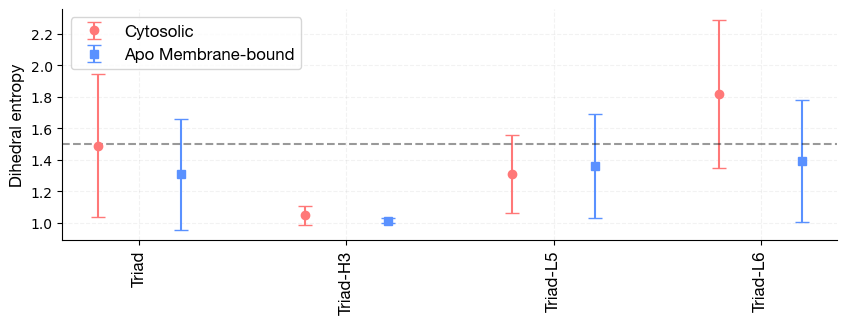

In [30]:
import matplotlib.pyplot as plt
import numpy as np

#  data
groups = [k for k in sel_regions.keys()][:]
x = np.arange(len(groups))  # numerical x-axis positions

pre_means = [np.mean(i) for i in region_wise_disorderness(pre_entropy_merger2['NET_ENTROPY'].to_list())]
pre_errors = [np.std(i) for i in region_wise_disorderness(pre_entropy_merger2['NET_ENTROPY'].to_list())]

unb_means = [np.mean(i) for i in region_wise_disorderness(unb_entropy_merger2['NET_ENTROPY'].to_list())]
unb_errors = [np.std(i) for i in region_wise_disorderness(unb_entropy_merger2['NET_ENTROPY'].to_list())]



fig, ax = plt.subplots(figsize=(10, 3))
# Create plot
# plt.figure(figsize=(10, 3))

# Plot Set 1
ax.errorbar(x - 0.2, pre_means, yerr=pre_errors, 
             fmt='o', capsize=5, label='Cytosolic', color='#FF7878')

# Plot Set 2
ax.errorbar(x + 0.2, unb_means, yerr=unb_errors, fmt='s', 
             capsize=5, label='Apo Membrane-bound', color='#5A91FF')

# Customize x-axis
ax.set_xticks(x, groups, rotation=90)
ax.set_xticklabels(groups,fontdict=font)

ax.set_ylabel('Dihedral entropy', fontdict=font)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.axhline(y=1.5, color='black', ls='--', alpha=0.4)
# plt.xlabel('Groups')
# plt.ylabel('Values')
# plt.title('Error Bar Plot for Two Sets per Group')
plt.legend(prop=rs)

# Show plot
# plt.tight_layout()
# plt.show()

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_SE_pre_unb_BB_CHI1_considered_region_wise.png',
            dpi=650,transparent=True,
               bbox_inches='tight')

In [26]:
sel_regions={'Triad':triad_res,
            'Triad-H3':[60,61,64,68],
            'Triad-L5':range(71,80),
            'Triad-L6':range(83,93)
            }

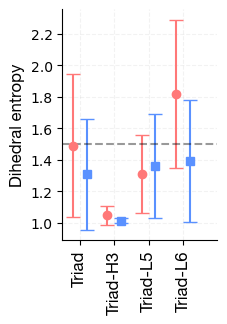

In [28]:
import matplotlib.pyplot as plt
import numpy as np

#  data
groups = [k for k in sel_regions.keys()][:]
x = np.arange(len(groups))  # numerical x-axis positions

pre_means = [np.mean(i) for i in region_wise_disorderness(pre_entropy_merger2['NET_ENTROPY'].to_list())]
pre_errors = [np.std(i) for i in region_wise_disorderness(pre_entropy_merger2['NET_ENTROPY'].to_list())]

unb_means = [np.mean(i) for i in region_wise_disorderness(unb_entropy_merger2['NET_ENTROPY'].to_list())]
unb_errors = [np.std(i) for i in region_wise_disorderness(unb_entropy_merger2['NET_ENTROPY'].to_list())]



fig, ax = plt.subplots(figsize=(2, 3))
# Create plot
# plt.figure(figsize=(10, 3))

# Plot Set 1
ax.errorbar(x - 0.2, pre_means, yerr=pre_errors, 
             fmt='o', capsize=5, label='Cytosolic', color='#FF7878')

# Plot Set 2
ax.errorbar(x + 0.2, unb_means, yerr=unb_errors, fmt='s', 
             capsize=5, label='Apo Membrane-bound', color='#5A91FF')

# Customize x-axis
ax.set_xticks(x, groups, rotation=90)
ax.set_xticklabels(groups,fontdict=font)

ax.set_ylabel('Dihedral entropy', fontdict=font)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.axhline(y=1.5, color='black', ls='--', alpha=0.4)
# plt.xlabel('Groups')
# plt.ylabel('Values')
# plt.title('Error Bar Plot for Two Sets per Group')
# plt.legend(prop=rs)

# Show plot
# plt.tight_layout()
# plt.show()

ax.set_xlim(-0.5,4)
plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_SE_pre_unb_BB_CHI1_considered_TRIAD.png',
            dpi=650,transparent=True,
               bbox_inches='tight')